# Example as from the CFM training script.

## Preparing notebook.

### Reload to incorporate recent changes.

In [1]:
%load_ext autoreload
%autoreload 2


### Libraries.

In [2]:
import os
import sys
import yaml

from hydra import initialize, compose
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import torch

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.constants import DataFields, PredictionFields
from sc_exp_design.data.container import DataMixin
from sc_exp_design.models import FlowMatching
from sc_exp_design.training.callbacks import WandBLogger, MetricsCallBack, TrainingCallBacks

sys.path.insert(0, "../../../scripts")

from data_utils import annotate_perturbations, apply_shared_transformations, get_protocol_tranformations
from ood_utils import split_adata
from train_utils import (
    parse_mlp_config_dictionary,
    parse_nested_mlp_config_dictionary,
    resolve_omegaconf_to_dictionary
)
from validation_utils import validate_on_ood_data, plot_marginals

### Constants.

In [3]:
IS_RUN_LOCALLY = False

time_samplers = {}
noise_distributions = {}
activation_functions = {}
optimizers = {}
schedulers = {}
state_transforms = {}
column2tranform = {}


### Reading configurations.

In [4]:
# Initialize Hydra with your config directory
with initialize(
    config_path="../config"
):
    # Compose the config (like what @hydra.main does)
    config = compose(
    config_name="train_cfm",
    overrides=[
        # "training=debug",
        "training.num_training_steps=500000",
        # "paths=hpc_subset",
        "data=ohe_protocols",
        "vf=default_ohe_protocols",
        # "data=ohe_protocols",
        # "vf=default_ohe_protocols",
        # "data=protocol_concat",
        # "vf=default_protocol_concat",
    ])

/tmp/ipykernel_469913/1364514590.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatibility version level, or None.
Will assume defaults for version 1.1
  with initialize(


## Data.

### Reading data.

In [5]:
adata = sc.read_h5ad(config.paths.h5ad_path)
adata

AnnData object with n_obs × n_vars = 93275454 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Annotating perturbations.

In [6]:
column2tranform = get_protocol_tranformations(
    config.annotation.protocol_columns,
    log1p_exp_cols=config.annotation.log1p_exp_cols,
    log21p_exp_cols=config.annotation.log21p_exp_cols,
) # TODO
adata = annotate_perturbations(
    adata,
    config.annotation.protocol_columns,
    protocol_obs_key_added=config.annotation.protocol_obs_key_added,
    protocol_sep=config.annotation.protocol_sep,
    one_hot_uns_key_added=config.annotation.one_hot_uns_key_added,
    column2tranform=column2tranform,
    protocol_obsm_key=config.annotation.protocol_obsm_key,
)
adata

AnnData object with n_obs × n_vars = 93275454 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[

### Splitting adata.

In [7]:
train_adata, ood_adatas_dict = split_adata(
    adata,
    # config.ood.obs_column,
    # config.ood.unique_value_ids,
    "days_of_culture",
    [5,], 
)
train_adata, ood_adatas_dict

(AnnData object with n_obs × n_vars = 92293092 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 's

### Applying shared transformations.

In [8]:
train_adata, ood_adatas_dict = apply_shared_transformations(
    train_adata,
    ood_adatas_dict,
    config.transforms.scatter_columns,
    compute_channel_pcs=config.transforms.compute_channel_pcs,
)
train_adata, ood_adatas_dict

(AnnData object with n_obs × n_vars = 92293092 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 's

### Visualizing applied transformations.

In [9]:
do_plot_marginals = False
if do_plot_marginals:
    obsm_to_plot = {
        'X_scatter': list(config.transforms.scatter_columns),
        'X_scatter_standardized': list(config.transforms.scatter_columns),
        'X_channel': train_adata.var_names.tolist(),
        'X_channel_standardized': train_adata.var_names.tolist(),
        'X_channel+X_scatter': train_adata.var_names.tolist() + list(config.transforms.scatter_columns),
        'X_channel_standardized+X_scatter': train_adata.var_names.tolist() + list(config.transforms.scatter_columns),
        'X_channel+X_scatter_standardized': train_adata.var_names.tolist() + list(config.transforms.scatter_columns),
        'X_channel_standardized+X_scatter_standardized': train_adata.var_names.tolist() + list(config.transforms.scatter_columns),
        'X_pca': [f"PC-{idx}" for idx in range(train_adata.obsm["X_pca"].shape[1])],
        'X_pca+X_scatter': [f"PC-{idx}" for idx in range(train_adata.obsm["X_pca"].shape[1])] + list(config.transforms.scatter_columns),
        'X_pca+X_scatter_standardized': [f"PC-{idx}" for idx in range(train_adata.obsm["X_pca"].shape[1])] + list(config.transforms.scatter_columns),
    }
    data = adata.X
    plot_marginals(data, title="Original Channel Features", col_names=train_adata.var_names.tolist())
    for key, names in obsm_to_plot.items():
        data = train_adata.obsm[key]
        plot_marginals(data, title=key, col_names=names)


## Model.

### Initializing CFM model.

In [10]:
flow_matching =  FlowMatching(
    flow_type=config.flow_matching.flow_type,
    flow_kwargs=resolve_omegaconf_to_dictionary(config.flow_matching.flow_kwargs),
    coupling_type=config.flow_matching.coupling_type,
    coupling_kwargs=resolve_omegaconf_to_dictionary(config.flow_matching.coupling_kwargs),
    time_sampler=time_samplers.get(config.flow_matching.time_sampler, torch.rand),
    device_id=config.flow_matching.device_id,
    generate_from_noise=config.flow_matching.generate_from_noise,
    noise_distribution=noise_distributions.get(config.flow_matching.noise_distribution, torch.randn),
)

### Setting up data.

In [ ]:
flow_matching.prepare_train_data(
    train_adata,
    sample_rep="X_channel_standardized+X_scatter_standardized",
    # sample_rep=config.data.sample_rep,
    control_key=config.data.control_key,
    perturbations=config.data.perturbations,
    perturbations_in_obsm=config.data.perturbations_in_obsm,
    perturbation_covariates=config.data.perturbation_covariates,
    perturbation_reps=config.data.perturbation_reps,
    load_target_covariates=config.data.load_target_covariates,
    target_covariates=config.data.target_covariates,
    target_covariates_in_obsm=config.data.target_covariates_in_obsm,
    target_covariates_kwargs=resolve_omegaconf_to_dictionary(config.data.target_covariates_kwargs),
)

### Prepare validation data.

In [14]:
for k, v in ood_adatas_dict.items():
    flow_matching.prepare_validation_data(k, v)

### Inspecting training data.

In [15]:
# col_names = train_adata.var_names.tolist() + list(config.transforms.scatter_columns)
# state_data = flow_matching.train_data.state_data
# plot_marginals(state_data, title="Input data", col_names=col_names)

### Initializing velocity field.

In [16]:
cvf_config = NeuralVelocityFieldConfig(
    flow_matching.train_data.state_data.shape[-1],
    encode_state=config.vf.encode_state,
    state_encoder_output_dim=config.vf.state_encoder_output_dim,
    state_encoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.state_encoder_mlp_kwargs),
    encode_time=config.vf.encode_time,
    use_sinusoidal_time_features=config.vf.use_sinusoidal_time_features,
    time_features_num_freqs=config.vf.time_features_num_freqs,
    time_features_max_periods=config.vf.time_features_max_periods,
    time_encoder_output_dim=config.vf.time_encoder_output_dim,
    time_encoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.time_encoder_mlp_kwargs),
    use_guidance=config.vf.use_guidance,
    encode_conditions=config.vf.encode_conditions,
    perturbation_encoder_output_dim=config.vf.perturbation_encoder_output_dim,
    perturbation_layers_before_pooling=parse_nested_mlp_config_dictionary(activation_functions, config.vf.perturbation_layers_before_pooling),
    perturbation_covariates_not_pooled=config.vf.perturbation_covariates_not_pooled,
    perturbation_pooling=config.vf.perturbation_pooling,
    perturbation_pooling_kwargs=config.vf.perturbation_pooling_kwargs,
    perturbation_layers_after_pooling=parse_mlp_config_dictionary(activation_functions, config.vf.perturbation_layers_after_pooling),
    decoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.decoder_mlp_kwargs),
    use_source_as_condition=config.vf.use_source_as_condition,
    encode_source=config.vf.encode_source, 
    source_encoder_output_dim=config.vf.source_encoder_output_dim,
    source_encoder_mlp_kwargs=parse_mlp_config_dictionary(activation_functions, config.vf.source_encoder_mlp_kwargs),
    conditioning_type=config.vf.conditioning_type,
    n_resnet_blocks=config.vf.n_resnet_blocks,
    resnet_dropout_prob=config.vf.resnet_dropout_prob,
    resnet_normalization=config.vf.resnet_normalization,
    use_classifier_free_guidance=config.vf.use_classifier_free_guidance,
    cfg_null_condition_token=config.vf.cfg_null_condition_token,
)

### Initializing Neural Velocity Field.

In [17]:
flow_matching.prepare_model(
    cvf_config,
    optimizer_class=optimizers.get(config.model.optimizer_id, torch.optim.Adam),
    optimizer_kwargs=resolve_omegaconf_to_dictionary(config.model.optimizer_kwargs),
    lr_scheduler_class=schedulers.get(config.model.scheduler_id, None),
    lr_scheduler_kwargs=resolve_omegaconf_to_dictionary(config.model.lr_scheduler_kwargs),
    lr_scheduler_step=config.model.lr_scheduler_step,
    num_time_steps=config.model.num_time_steps,
    solver_kwargs=resolve_omegaconf_to_dictionary(config.model.solver_kwargs),
)
print(flow_matching.velocity_field)

NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=27, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (condition_encoder): ConditionEncoder(
      (modules_dict): ModuleDict(
        (repr_protocol_id_one_hot): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=117, out_features=16, bias=True)
              (1): ReLU()
            )
    

### Prepare training callbacks.

In [18]:
wandb_callback = WandBLogger(
    project_name=config.callbacks.wandb_project_name,
    log_dir=config.paths.log_dir,
    config=config,
    **resolve_omegaconf_to_dictionary(config.callbacks.wandb_kwargs),
)
metrics_callback = MetricsCallBack(
    config.callbacks.metrics,
    state_transforms=state_transforms.get(config.training.state_transforms, None),
)
callbacks = TrainingCallBacks(
    [
        wandb_callback,
        metrics_callback
    ]
)

### Train CFM.

In [19]:
flow_matching.train(
    num_training_steps=config.training.num_training_steps,
    valid_freq=config.training.valid_freq,
    train_batch_size=config.training.train_batch_size,
    validation_batch_size=config.training.validation_batch_size,
    state_transforms=state_transforms.get(config.training.state_transforms, None),
    callbacks=callbacks,
    grad_steps_log_interval=config.training.grad_steps_log_interval,
    num_treatments_to_load=config.training.num_treatments_to_load,
    num_samples_per_validation_step=config.training.num_samples_per_validation_step,
    cfg_prob_unconditional=config.training.cfg_prob_unconditional,
    validation_cfg_guidance_strength=config.training.validation_cfg_guidance_strength,
    num_grad_accumulation_steps=config.training.num_grad_accumulation_steps,
    close_wandb_connection=False,
)

  0%|          | 0/500000 [00:00<?, ?it/s]wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: fmgs666 (inverse-perturbation-models) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loss: 1.3602:  20%|██        | 100000/500000 [10:19<39:34, 168.45it/s] 

OutOfMemoryError: CUDA out of memory. Tried to allocate 315.12 GiB. GPU 0 has a total capacity of 79.25 GiB of which 75.46 GiB is free. Including non-PyTorch memory, this process has 3.78 GiB memory in use. Of the allocated memory 3.26 GiB is allocated by PyTorch, and 27.99 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Plotting training logs.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

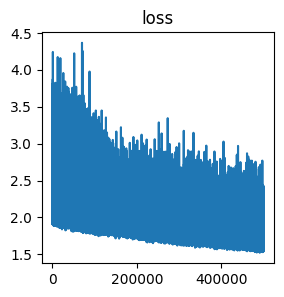

: 

In [ ]:
flow_matching.trainer.plot_training_logs()

### Validation.

In [ ]:
def predict_on_ood_data(
    N,
    flow_matching,
    ood_data,
):
    perturbation_data = ood_data.perturbation_data
    assert perturbation_data is not None
    if ood_data.seen_combinations is not None:
        perturbation_data = DataMixin(ood_data.perturbation_data)
        comb2pred = {}
        # iterating over unique combinations
        for comb in ood_data.seen_combinations:
            comb_idxs = np.all((ood_data.adata.obs[flow_matching.data_manager.perturbations] == comb).values, axis=-1)
            comb_adata = ood_data.adata[comb_idxs]
            comb_data = flow_matching.data_manager.get_data(comb_adata)
            comb_perts = DataMixin(comb_data.perturbation_data)
            comb_perts = comb_perts.apply(lambda x: np.unique(x, axis=0))
            comb_perts = comb_perts.apply(lambda x: torch.from_numpy(x).float().to(flow_matching.device).repeat(N, 1))
            preds = flow_matching.predict(
                {
                    DataFields.PERTURBATION_DATA: comb_perts,
                },
            ).detach().cpu().numpy()
            comb2pred[comb] = {
                PredictionFields.PREDICTION_DATA: preds,
                DataFields.TARGET_STATE: comb_data.state_data
            }

    # paired setting TODO
    else:
        comb2pred = {}
        perturbation_data = DataMixin(ood_data.perturbation_data)
        unique_perts = perturbation_data.apply(lambda x: np.unique(x, axis=0))
        print("unique_perts ", next(iter(unique_perts.values())).shape)
        for idx in range(next(iter(unique_perts.values())).shape[0]):
            comb_perts = unique_perts.apply(lambda x: x[idx, :])
            print("ood_data", next(iter(perturbation_data.values())).shape)
            print("comb_perts", next(iter(comb_perts.values())).shape)
            comb_idxs = np.all(next(iter(perturbation_data.values())) == next(iter(comb_perts.values())), axis=-1)
            print("comb_idxs", comb_idxs.shape)

            comb_adata = ood_data.adata[comb_idxs]
            comb_data = flow_matching.data_manager.get_data(comb_adata)
            comb_perts = comb_perts.apply(lambda x: torch.from_numpy(x[None]).float().to(flow_matching.device).repeat(N, 1))
            print(comb_perts)
            preds = flow_matching.predict(
                {
                    DataFields.PERTURBATION_DATA: comb_perts,
                },
            ).detach().cpu().numpy()
            comb2pred[idx] = {
                PredictionFields.PREDICTION_DATA: preds,
                DataFields.TARGET_STATE: comb_data.state_data
            }

    return comb2pred

def validate_on_ood_data(
    N,
    flow_matching,
    ood_data,
    metrics_callback,
):
    metrics_input = predict_on_ood_data(
        N, flow_matching, ood_data
    )
    return metrics_callback.run_on_valid_step(
        metrics_input
    )

In [ ]:
N = 1000
num_time_steps = 100
sep = "+"
splits_metrics_dict = {}
for split_id, split_data in ood_data_dict.items():
    splits_metrics_dict[split_id] = validate_on_ood_data(
        N,
        flow_matching,
        split_data,
        callbacks,
    )
callbacks.run_on_train_end()